# MODELIZACIÓN REGRESION EXPOSURE AT DEFAULT

## IMPORTAR PAQUETES

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV, KFold

from sklearn.metrics import mean_absolute_error

#Autocompletar rápido
%config IPCompleter.greedy=True

#Desactivar la notación científica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
from credit_scoring.config import PROCESSED_DATA_DIR

ruta_proyecto = PROCESSED_DATA_DIR

2026-09-15 16:20:40.057 | INFO     | credit_scoring.config:<module>:11 - PROJ_ROOT path is: /home/isailzc/credit_scoring/credit_scoring


Nombres de los archivos de datos.

In [3]:
nombre = 'df_tablon_ead.pickle'

Cargar los datos.

In [4]:
df = pd.read_pickle(ruta_proyecto / nombre)

## CREAR X e Y

In [5]:
x = df.drop(columns='target_ead')
y = df.target_ead

In [6]:
y.describe()

count   139054.00
mean         0.34
std          0.37
min          0.00
25%          0.00
50%          0.13
75%          0.73
max          1.00
Name: target_ead, dtype: float64

## MODELIZAR

### Reservar el dataset de validacion

In [7]:
train_x,val_x,train_y,val_y = train_test_split(x,y,test_size=0.3, random_state=42)

### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

In [10]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([('algoritmo', Ridge())])

grid = [      
    {
        'algoritmo': [Ridge()],  # Determinista por defecto
        'algoritmo__alpha': list(np.arange(0.1, 1.1, 0.1))
    },
    {
        'algoritmo': [Lasso(random_state=42)],  # Semilla aplicada
        'algoritmo__alpha': list(np.arange(0.1, 1.1, 0.1))
    },
    {
        # Semilla aplicada y sin 'scoring' interno
        'algoritmo': [HistGradientBoostingRegressor(min_samples_leaf=100, random_state=42)],
        'algoritmo__learning_rate': [0.01, 0.025, 0.05, 0.1],
        'algoritmo__max_iter': [50, 100, 200],
        'algoritmo__max_depth': [5, 10, 20],
        'algoritmo__l2_regularization': [0, 0.25, 0.5, 0.75, 1]
    }
]

### Optimizar los hiper parámetros

####  Con grid search

In [11]:
grid_search = GridSearchCV(
    estimator=pipe, 
    param_grid=grid, 
    cv=cv_strategy,  
    scoring='neg_mean_absolute_percentage_error',
    verbose=0,
    n_jobs=-1
)

modelo = grid_search.fit(train_x,train_y)

In [12]:
salida = pd.DataFrame(grid_search.cv_results_).sort_values(by = 'rank_test_score').reset_index(drop=True).head(10)
salida

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__alpha,param_algoritmo__l2_regularization,param_algoritmo__learning_rate,param_algoritmo__max_depth,param_algoritmo__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,16.30,1.99,1.42,0.31,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.25,0.10,10,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-495499843519972.75,-505551807746940.62,-503238226479862.81,-488783753132046.94,-511923984632168.00,-500999523102198.19,8056679955049.87,1
1,17.16,2.67,1.45,0.33,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.25,0.10,20,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-495898279049447.88,-506735928886808.75,-501885347401355.88,-489288316556643.25,-511562649823011.69,-501074104343453.50,7853889736497.31,2
2,17.06,1.92,1.57,0.19,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.75,0.10,20,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-497654677655377.06,-507473533084150.12,-499935999038631.44,-491351333075333.88,-509109459160600.69,-501105000402818.62,6527402026908.55,3
3,17.09,2.96,1.34,0.27,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0,0.10,10,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-493786059371821.19,-506657564301740.19,-503021186162722.69,-491996588972151.94,-511196642558422.69,-501331608273371.69,7383999946984.91,4
4,19.83,1.24,1.54,0.24,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.50,0.10,10,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-496648476657584.50,-507343824760680.06,-501912801867806.38,-490457806392364.56,-510956908558489.19,-501463963647384.88,7337774022361.09,5
5,17.77,2.11,1.44,0.24,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.75,0.10,10,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-496195104897754.31,-509527642997634.38,-501296673771740.50,-488275050072050.88,-512580848645021.25,-501575064076840.19,8834960553515.43,6
6,18.92,2.86,1.57,0.14,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.50,0.10,20,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-495130721954704.94,-505788155498744.25,-501085162058101.25,-489148752702479.81,-517382188958006.06,-501706996234407.31,9630275900666.01,7
7,17.74,3.49,1.37,0.22,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0,0.10,20,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-494003657063185.31,-507763797157706.31,-501736130825383.75,-491341549271126.19,-514400863176107.00,-501849199498701.81,8538182013473.83,8
8,14.90,1.43,1.25,0.10,HistGradientBoostingRegressor(l2_regularizatio...,NaN,1,0.10,10,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-498493578354881.25,-507690000793707.94,-502959654841879.12,-491622888925829.31,-511844859059405.31,-502522196395140.62,7054562750036.86,9
9,11.75,1.39,0.71,0.19,HistGradientBoostingRegressor(l2_regularizatio...,NaN,1,0.10,20,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-495980770544175.44,-509837793426725.69,-501616692159718.12,-490374293180632.94,-518443663213786.75,-503250642505007.81,9955296474781.38,10


En todas las primeras configuraciones tenemos el LightGBM.

Por sencillez nos quedamos con el primero.

Y reentreamos el modelo con esa configuración.

In [13]:
modelo_ead = HistGradientBoostingRegressor(learning_rate = 0.1,
                                          max_iter = 200,
                                          max_depth = 10,
                                          min_samples_leaf = 100,
                                          scoring = 'neg_mean_absolute_percentage_error',
                                          l2_regularization = 0.25,
                                          random_state=42)
modelo_ead.fit(train_x,train_y)

HistGradientBoostingRegressor(l2_regularization=0.25, max_depth=10,
                              max_iter=200, min_samples_leaf=100,
                              random_state=42,
                              scoring='neg_mean_absolute_percentage_error')

## EVALUAR

### Predecir sobre validación

In [14]:
pred = modelo_ead.predict(val_x)

Corregimos los máximos y mínimos.

In [15]:
pred = np.where(pred < 0, 0, pred)
pred = np.where(pred > 1, 1, pred)

### Evaluar sobre validación

In [16]:
mean_absolute_error(val_y, pred)

0.23195752719158472

## REPORTING DEL MODELO

In [17]:
check_validacion = pd.DataFrame({'ead_real':val_y, 'ead_pred':pred})
check_validacion

,ead_real,ead_pred
id_cliente,,
58390566,0.40,0.27
81563640,0.09,0.07
39672325,0.00,0.18
140399151,0.87,0.56
63074656,0.00,0.40
...,...,...
86216693,0.00,0.23
97487990,0.29,0.16
76254062,0.00,0.38


In [18]:
check_validacion.corr()

,ead_real,ead_pred
ead_real,1.00,0.64
ead_pred,0.64,1.00


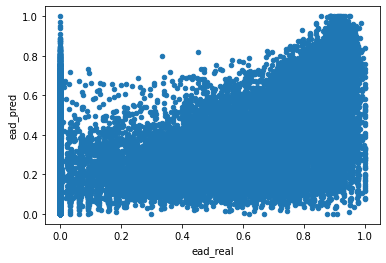

In [19]:
check_validacion.plot.scatter(x='ead_real',y='ead_pred');

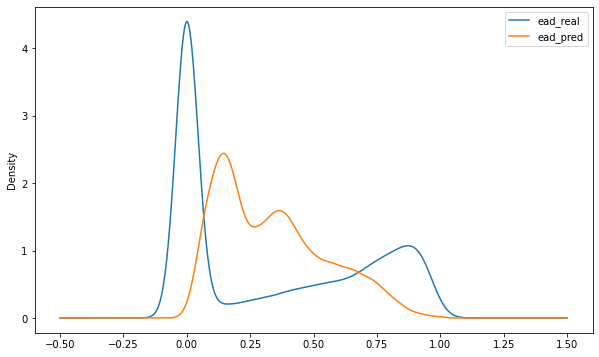

In [20]:
check_validacion.plot.density(figsize = (10,6));